In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(deliveries.shape)
matches.head()

(1095, 20)
(260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [ ]:
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [ ]:
matches = matches.dropna(subset=['winner'])
matches['city'] = matches['city'].fillna('unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('unknown')

print(matches.isnull().sum())

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [ ]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:

win_counts = matches['winner'].value_counts()
print(win_counts)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


## Visualization 1: Most Matches Won by Each Team
**Insight:** Mumbai Indians have won the most matches in IPL history,
followed by Chennai Super Kings. These two teams are the most
consistent performers in IPL.

/tmp/ipykernel_3515/1220857522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.values, y=win_counts.index, palette='rocket')


Text(0, 0.5, 'Team')

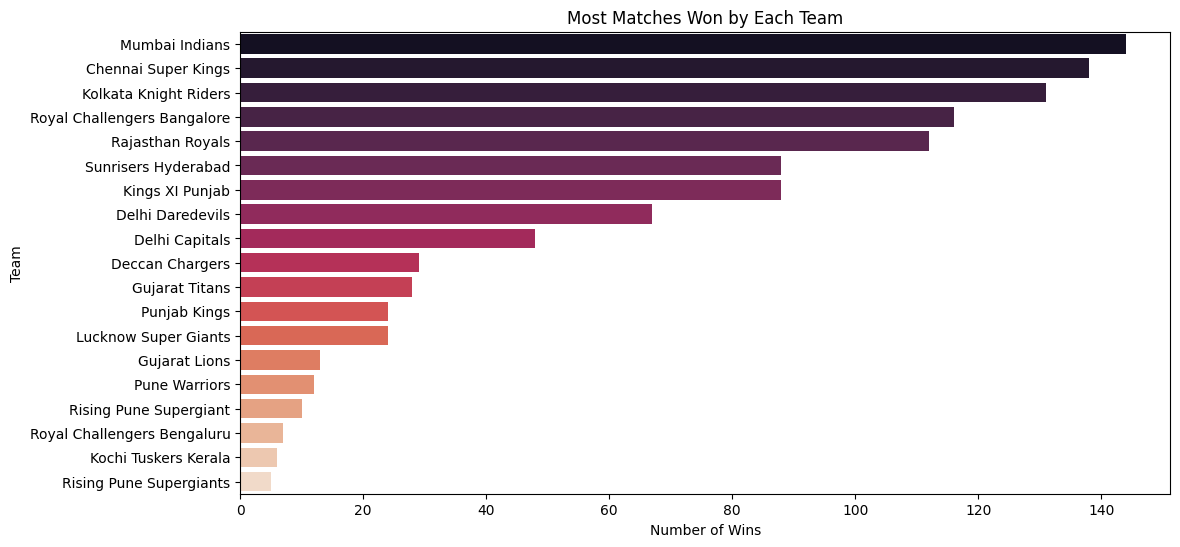

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=win_counts.values, y=win_counts.index, palette='rocket')
plt.title('Most Matches Won by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

## Visualization 2: Toss Winner vs Match Winner
**Insight:** Winning the toss does not guarantee winning the match.
Nearly 50% of the time, the toss winner goes on to lose the match.

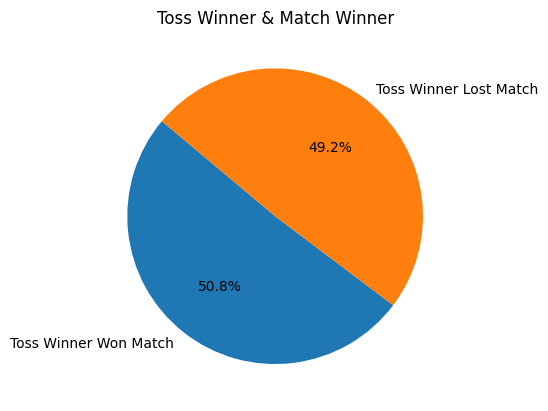

In [ ]:
toss_win = matches[matches['toss_winner'] == matches['winner']]
toss_loss = matches[matches['toss_winner'] != matches['winner']]
label = ['Toss Winner Won Match', 'Toss Winner Lost Match']
sizes = [len(toss_win), len(toss_loss)]
plt.pie(sizes, labels=label, autopct='%1.1f%%', startangle=140)
plt.title('Toss Winner & Match Winner')
plt.show()

## Visualization 3: Top 10 Run Scorers
**Insight:** Virat Kohli leads the all-time run scoring charts in IPL,
followed by Rohit Sharma. Both players have been incredibly consistent
over the years.

/tmp/ipykernel_3515/2299266304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma', legend="false" )


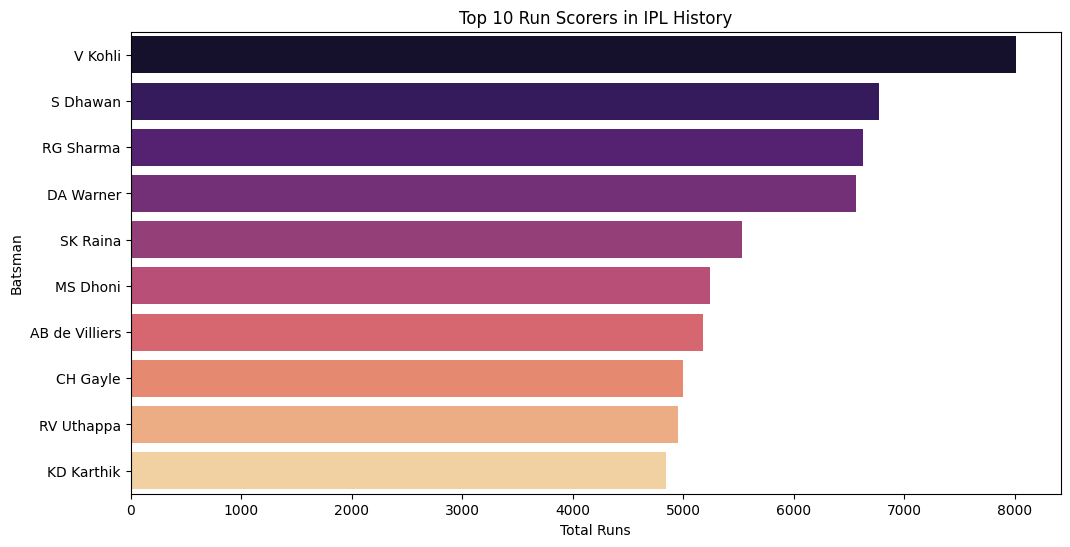

In [ ]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma', legend="false" )
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

## Visualization 4: Top 10 Wicket Takers
**Insight:** Lasith Malinga is the highest wicket taker in IPL history
(2008-2020). His yorker deliveries made him nearly unplayable in
death overs.

/tmp/ipykernel_3515/2911438535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='coolwarm')


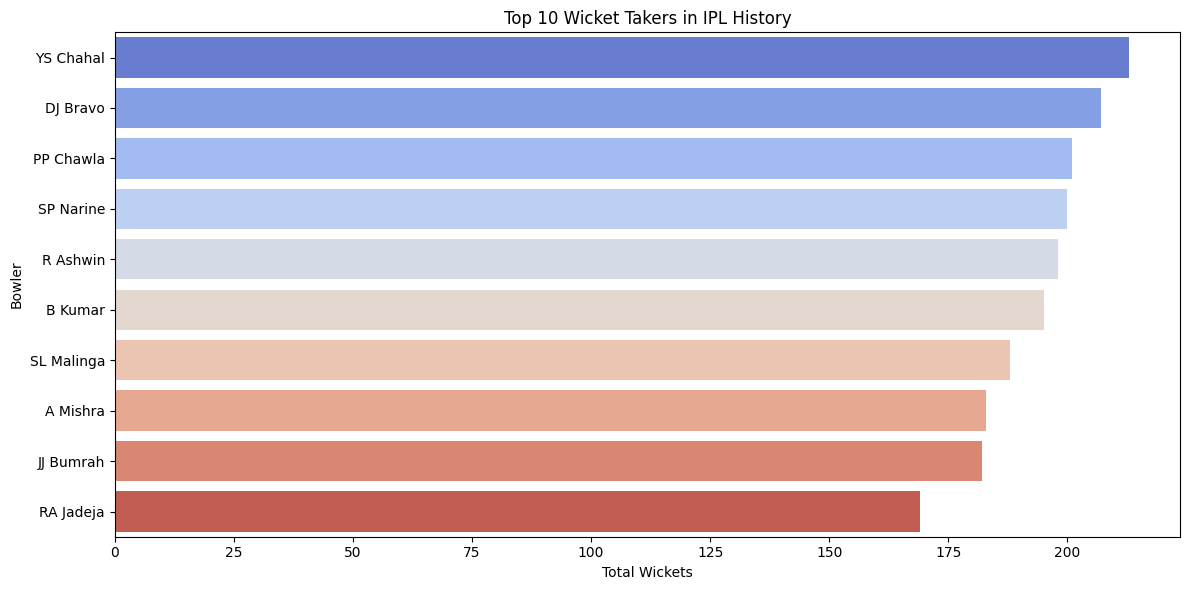

In [ ]:
wickets = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='coolwarm')
plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

## Visualization 5: Season-wise Total Runs
**Insight:** Total runs scored per season has increased over the years,
indicating that batting has become more dominant in IPL over time.

   match_id  total_runs
0    335982         304
1    335983         447
2    335984         261
3    335985         331
4    335986         222


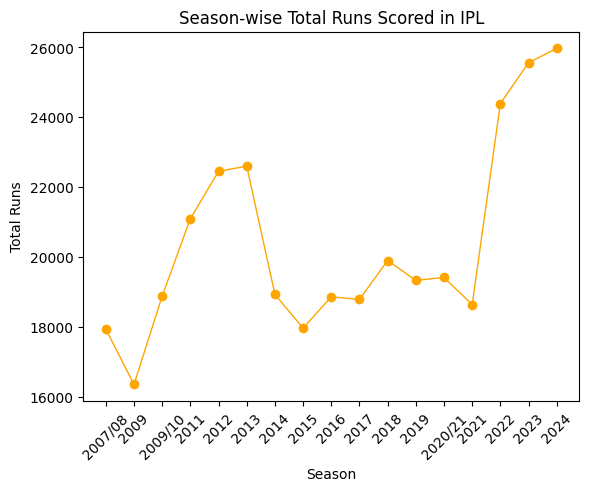

season
2007/08    17937
2009       16353
2009/10    18883
2011       21098
2012       22453
2013       22602
2014       18931
2015       17964
2016       18862
2017       18786
2018       19901
2019       19331
2020/21    19416
2021       18637
2022       24395
2023       25563
2024       25971
Name: total_runs, dtype: int64


In [ ]:
match_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
print(match_runs.head())
season_runs = match_runs.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum()
plt.plot(season_total.index, season_total.values, marker='o', color='orange', linewidth=1)
plt.title('Season-wise Total Runs Scored in IPL')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.show()
print(season_total)

In [ ]:
from google.colab import files
uploaded = files.upload()

## Visualization 6: Most Player of the Match Awards
**Insight:** AB de Villiers and Chris Gayle have won the most
Player of the Match awards in IPL history. Their match-winning
performances have been extraordinary over the years.

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


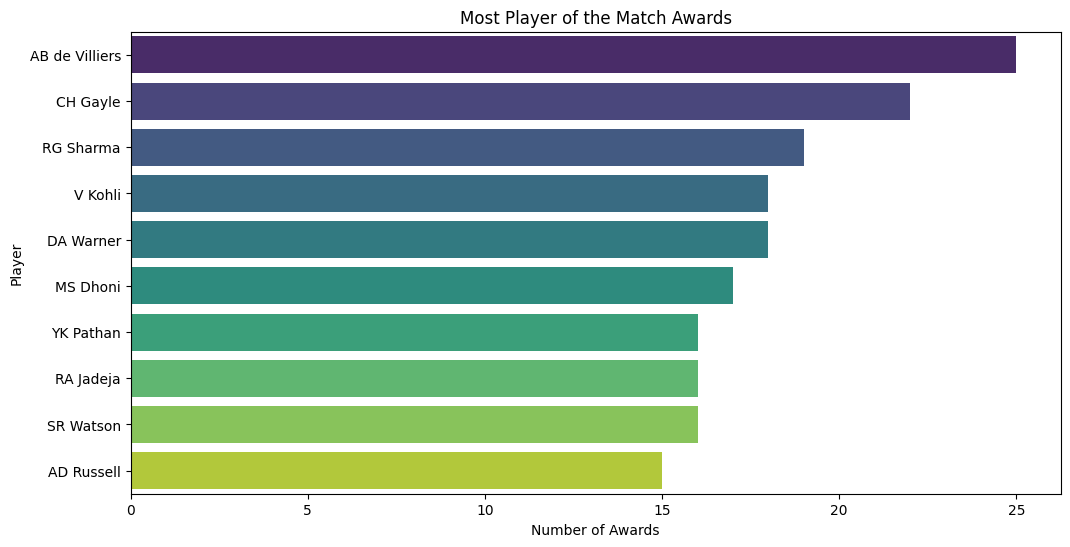

In [ ]:
top_players = matches['player_of_match'].value_counts().head(10)
print(top_players)
plt.figure(figsize=(12,6))
sns.barplot(x=top_players.values, y=top_players.index, hue=top_players.index, palette='viridis')
plt.title('Most Player of the Match Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.show()

In [ ]:
each_match_fours = deliveries[deliveries['batsman_runs']==4].groupby('match_id')['batsman_runs'].count().reset_index()
each_match_sixes = deliveries[deliveries['batsman_runs']==6].groupby('match_id')['batsman_runs'].count().reset_index()
print(each_match_fours.head())
print(each_match_sixes.head())



   match_id  batsman_runs
0    335982            18
1    335983            38
2    335984            32
3    335985            33
4    335986            11
   match_id  batsman_runs
0    335982            17
1    335983            25
2    335984             4
3    335985            11
4    335986            10


In [ ]:
fours = each_match_fours.merge(matches[['id','season']], left_on='match_id', right_on='id')
sixes = each_match_sixes.merge(matches[['id','season']], left_on='match_id', right_on='id')
print(fours.head())
print(sixes.head())

   match_id  batsman_runs      id   season
0    335982            18  335982  2007/08
1    335983            38  335983  2007/08
2    335984            32  335984  2007/08
3    335985            33  335985  2007/08
4    335986            11  335986  2007/08
   match_id  batsman_runs      id   season
0    335982            17  335982  2007/08
1    335983            25  335983  2007/08
2    335984             4  335984  2007/08
3    335985            11  335985  2007/08
4    335986            10  335986  2007/08


In [ ]:
season_fours = fours.groupby('season')['batsman_runs'].count()
season_sixes = sixes.groupby('season')['batsman_runs'].count()
print(season_fours)
print(season_sixes)

season
2007/08    58
2009       57
2009/10    60
2011       72
2012       74
2013       76
2014       60
2015       57
2016       60
2017       59
2018       60
2019       59
2020/21    60
2021       60
2022       74
2023       73
2024       71
Name: batsman_runs, dtype: int64
season
2007/08    58
2009       57
2009/10    60
2011       72
2012       74
2013       76
2014       60
2015       57
2016       60
2017       59
2018       60
2019       59
2020/21    60
2021       60
2022       74
2023       73
2024       71
Name: batsman_runs, dtype: int64


## Visualization 7: Season-wise Fours and Sixes
**Insight:** 2013 season had the most boundaries in IPL history.
Over the years, the number of sixes has increased significantly,
showing that batsmen are playing more aggressively.

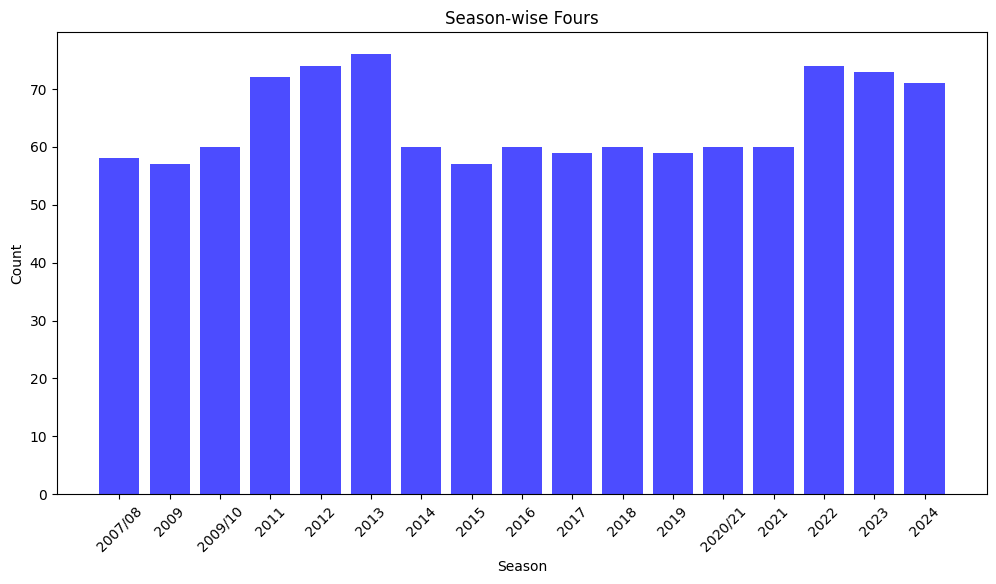

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(season_fours.index, season_fours.values, label='Fours', color='blue', alpha=0.7)
plt.title('Season-wise Fours')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

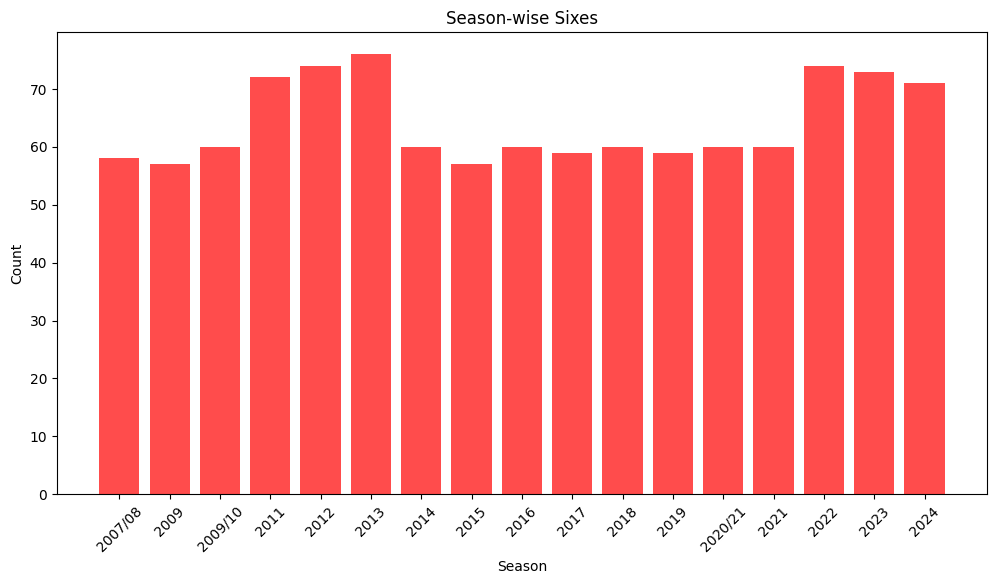

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(season_sixes.index, season_sixes.values, label='Sixes', color='red', alpha=0.7)
plt.title('Season-wise Sixes')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Visualization 8: Winning by Runs vs Wickets
**Insight:** More matches are won by wickets than by runs in IPL.
This shows that chasing teams have a slight advantage over
defending teams.

In [ ]:
win_by_runs = matches[matches['result'] == 'runs']['result'].count()
win_by_wickets = matches[matches['result'] == 'wickets']['result'].count()

print(win_by_runs)
print(win_by_wickets)

498
578


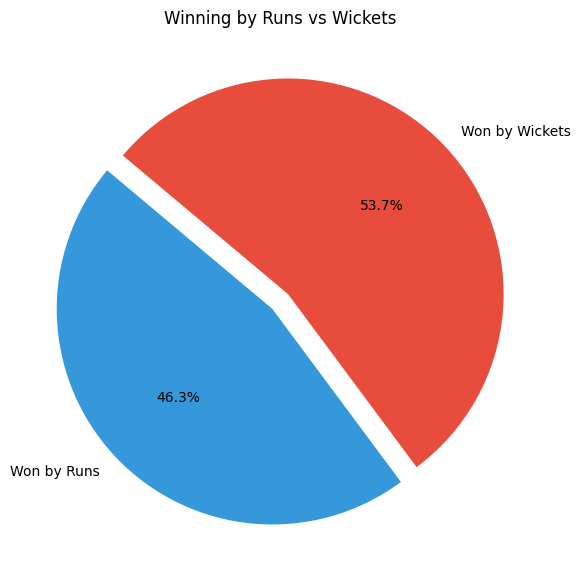

In [ ]:
labels = ['Won by Runs', 'Won by Wickets']
sizes = [win_by_runs, win_by_wickets]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#3498DB','#E74C3C'], startangle=140,
        explode=(0.05, 0.05))
plt.title('Winning by Runs vs Wickets')
plt.show()

## Visualization 9: Top 10 Venues by Number of Matches
**Insight:** Wankhede Stadium and M. Chinnaswamy Stadium have
hosted the most IPL matches. These venues are known for their
batting-friendly pitches and electric atmospheres.

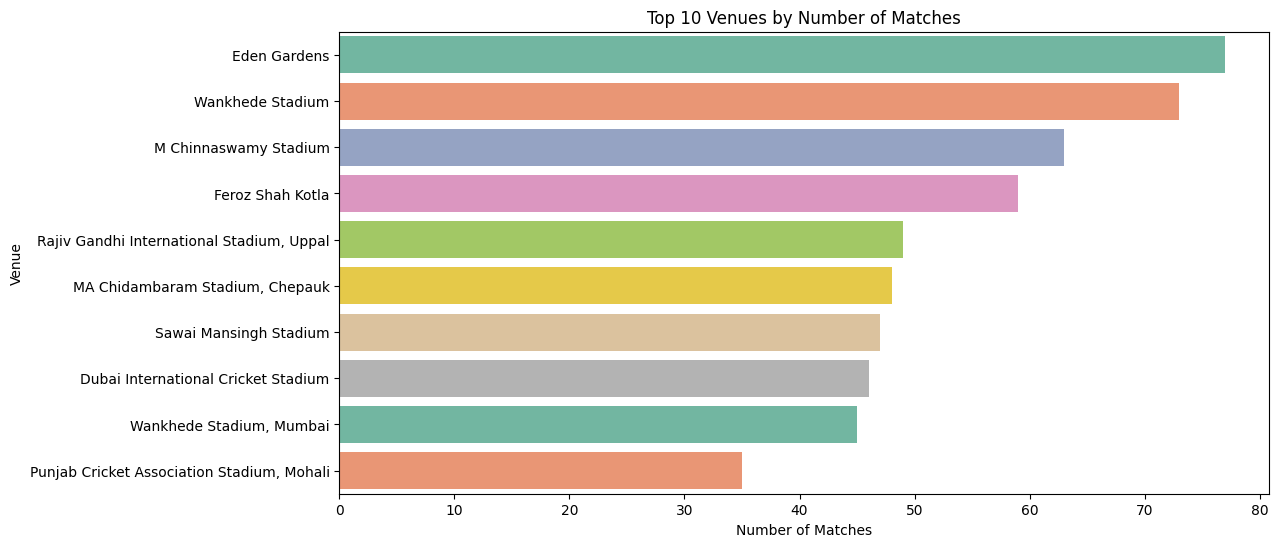

In [ ]:
top_venues = matches['venue'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_venues.values, y=top_venues.index,
            hue=top_venues.index, palette='Set2')
plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

## Visualization 10: Top 10 Batsmen by Average Runs per Ball
**Insight:** Hard-hitting batsmen dominate the average runs per
ball chart. These players have the ability to score quickly and
change the game in a few overs.

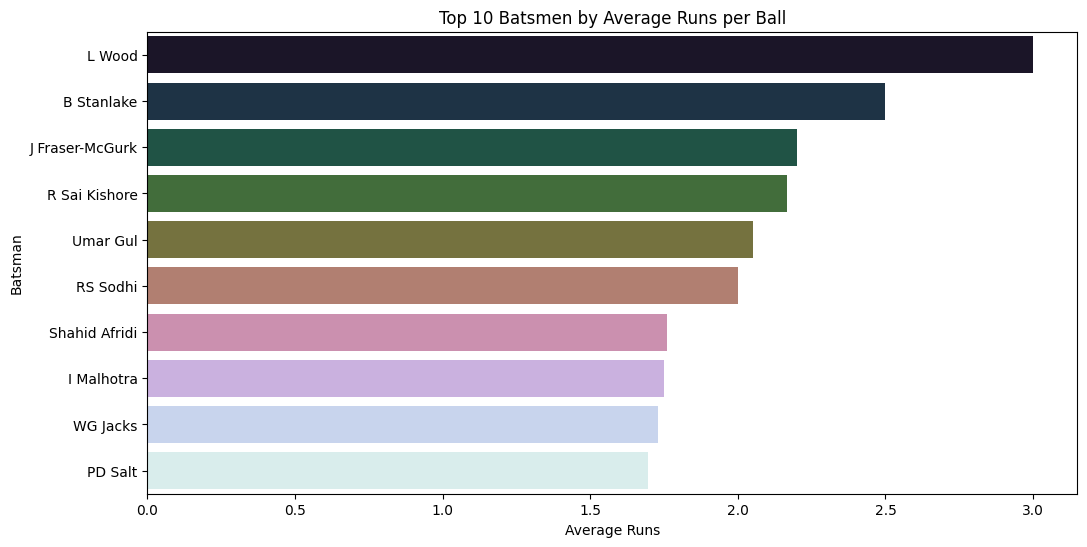

In [ ]:
avg_runs = deliveries.groupby('batter')['batsman_runs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_runs.values, y=avg_runs.index,
            hue=avg_runs.index, palette='cubehelix')
plt.title('Top 10 Batsmen by Average Runs per Ball')
plt.xlabel('Average Runs')
plt.ylabel('Batsman')
plt.show()

## Conclusion
This analysis of IPL data from 2008 to 2024 reveals that Mumbai
Indians are the most successful team, Virat Kohli is the leading
run scorer, and batting has become more dominant over the years.
Toss winning does not significantly impact match results.